Extraction complete.
Filtering complaints for: 2010
Records found for 2010: 5025
Complaints data processed successfully.
    NTA2020      Dominant_Type
622  QN0602  Missed Collection
837  SI0302  Missed Collection
656  QN0801  Missed Collection
845  SI0304  Missed Collection
819  SI0202  Missed Collection
Shapefile loaded successfully.


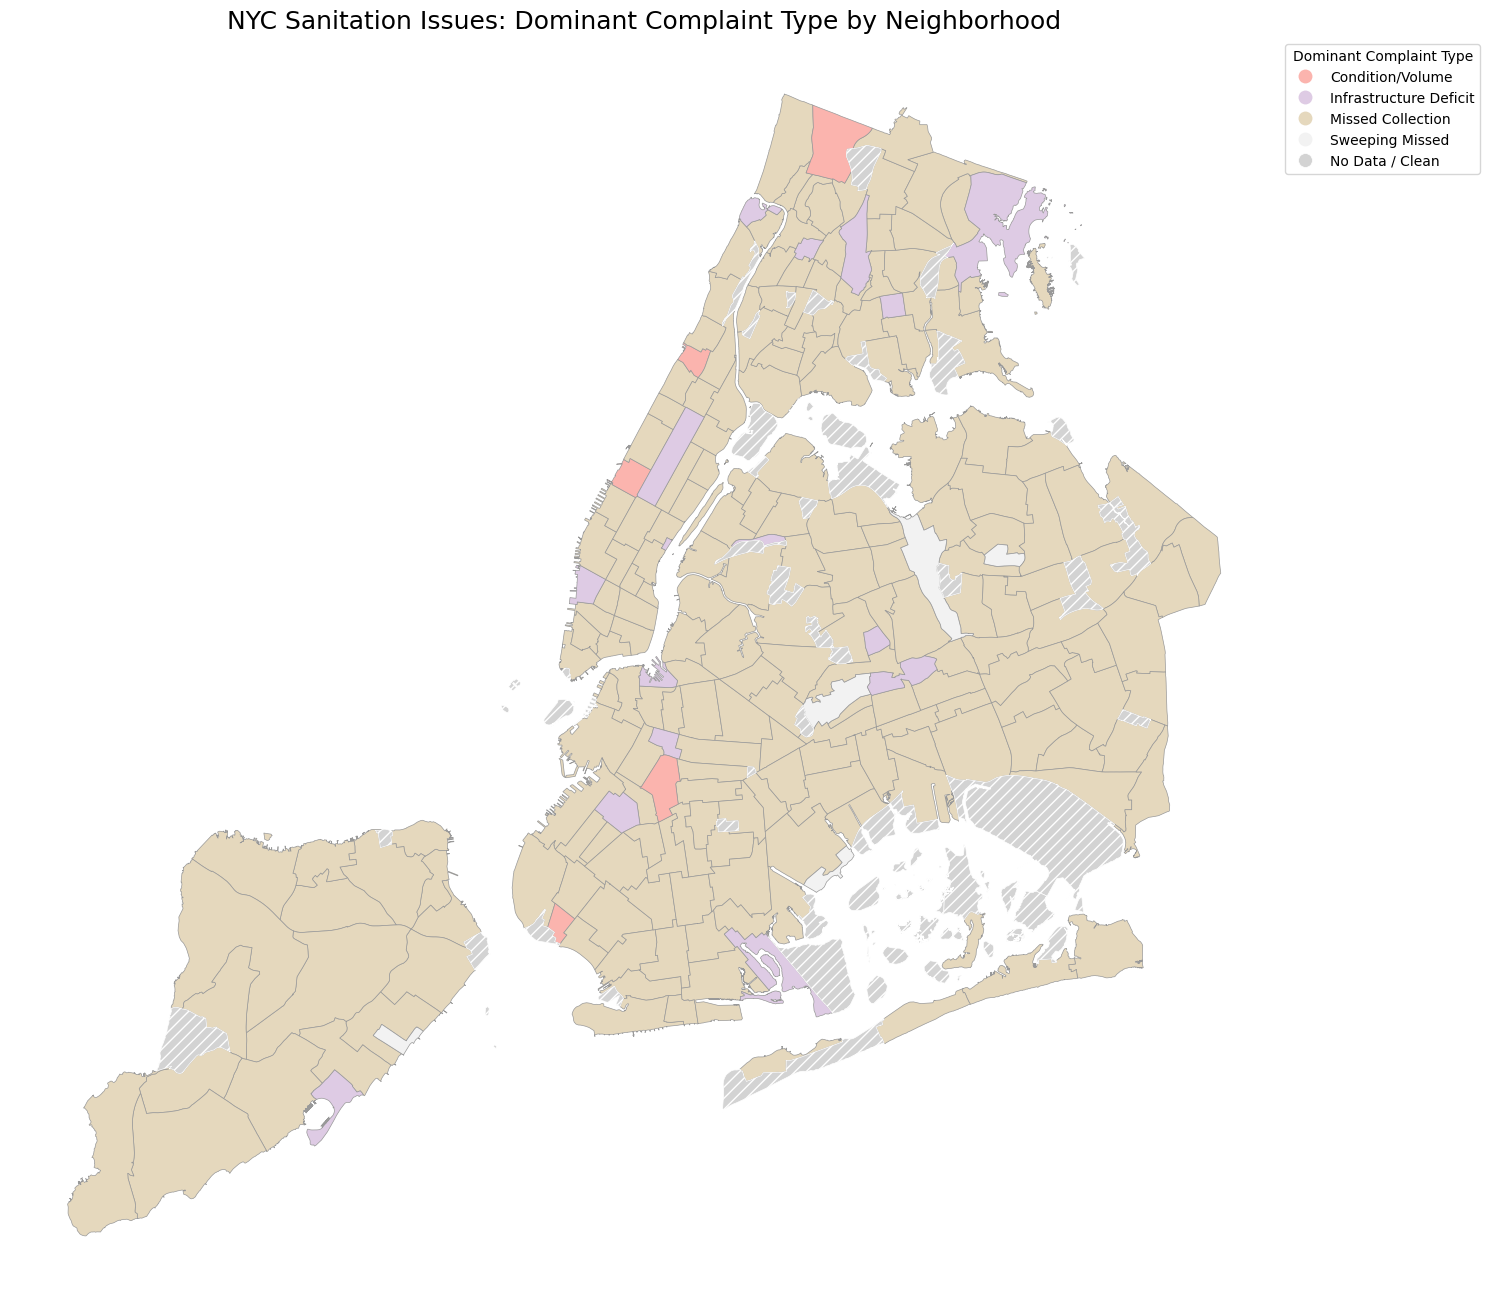

In [41]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import zipfile
import os

zip_file_path = '../nyc311/nynta2020_25d.zip'
extract_dir = 'nynta2020_25d'

if not os.path.exists(extract_dir):
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("Extraction complete.")
    except FileNotFoundError:
        print(f"Error: The file '{zip_file_path}' was not found.")
        pass 

shp_file_path = os.path.join(extract_dir, 'nynta2020_25d', 'nynta2020.shp')

csv_path = '311_compliants.csv'
df_complaints = pd.read_csv(csv_path)

filter_time = '2010'  

print(f"Filtering complaints for: {filter_time}")
df_complaints = df_complaints[df_complaints['year_month'].astype(str).str.startswith(filter_time)].copy()

print(f"Records found for {filter_time}: {len(df_complaints)}")

# print(f"Original records: {len(df_complaints)}")
# df_complaints = df_complaints[df_complaints['Complaint Type'] != 'Request Large Bulky Item Collection']
# print(f"Records after exclusion: {len(df_complaints)}")


category_map = {
    'Litter Basket Request': 'Infrastructure Deficit',
    'Litter Basket / Request': 'Infrastructure Deficit',
    'Adopt-A-Basket': 'Infrastructure Deficit',
    
    'Missed Collection': 'Missed Collection',
    'Missed Collection (All Materials)': 'Missed Collection',

    'Sweeping/Missed': 'Sweeping Missed',
    'Sweeping/Missed-Inadequate': 'Sweeping Missed',
    'Sweeping/Inadequate': 'Sweeping Missed',
    'Street Sweeping Complaint': 'Sweeping Missed',

    'Collection Truck Noise': 'Service Failure',
    'Request Large Bulky Item Collection': 'Service Failure',
    'Request Xmas Tree Collection': 'Service Failure',
    
    'Overflowing Litter Baskets': 'Condition/Volume',
    'Overflowing Recycling Baskets': 'Condition/Volume',
    'Litter Basket Complaint': 'Condition/Volume', 
    'Recycling Basket Complaint': 'Condition/Volume'
}

df_complaints['Complaint_Category'] = df_complaints['Complaint Type'].map(category_map).fillna('Other')

nta_cat_counts = df_complaints.groupby(['NTA2020', 'Complaint_Category'])['complaint_count'].sum().reset_index()

df_dominant = nta_cat_counts.sort_values('complaint_count', ascending=False).drop_duplicates('NTA2020')

df_subset = df_dominant[['NTA2020', 'Complaint_Category']].copy()
df_subset.rename(columns={'Complaint_Category': 'Dominant_Type'}, inplace=True)
df_subset['NTA2020'] = df_subset['NTA2020'].astype(str)

print("Complaints data processed successfully.")
print(df_subset.head())


try:
    nyc_nta_geo = gpd.read_file(shp_file_path)
    nyc_nta_geo['NTA2020'] = nyc_nta_geo['NTA2020'].astype(str)
    print("Shapefile loaded successfully.")

    nta_merged = nyc_nta_geo.merge(df_subset, on='NTA2020', how='left')
    fig, ax = plt.subplots(1, 1, figsize=(15, 15))

    nta_merged.plot(
        column='Dominant_Type', 
        categorical=True,       
        cmap='Pastel1', 
        linewidth=0.5,
        ax=ax,
        edgecolor='0.6',        
        legend=True,
        legend_kwds={
            'title': "Dominant Complaint Type",
            'loc': 'upper left',
            'bbox_to_anchor': (1, 1)
        },
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "white",
            "hatch": "///",
            "label": "No Data / Clean"
        }
    )

    # Add title and cleanup
    ax.set_title('NYC Sanitation Issues: Dominant Complaint Type by Neighborhood', fontsize=18)
    ax.set_axis_off() 

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Could not load shapefile or plot map: {e}")
    print("Ensure the 'nynta2020_25d.zip' file is in the correct directory.")

Population data loaded.
Filtering complaints for: 2024
Records found for 2024: 6244
       Total_Complaints     Population   Intensity
count        218.000000     210.000000  218.000000
mean         212.270642  148750.333333    1.512856
std          154.222071   43930.457396    1.143438
min            1.000000   51673.000000    0.000000
25%          106.250000  113257.000000    0.699941
50%          192.000000  151107.000000    1.305307
75%          282.750000  181981.000000    2.115516
max          741.000000  247354.000000    6.627893


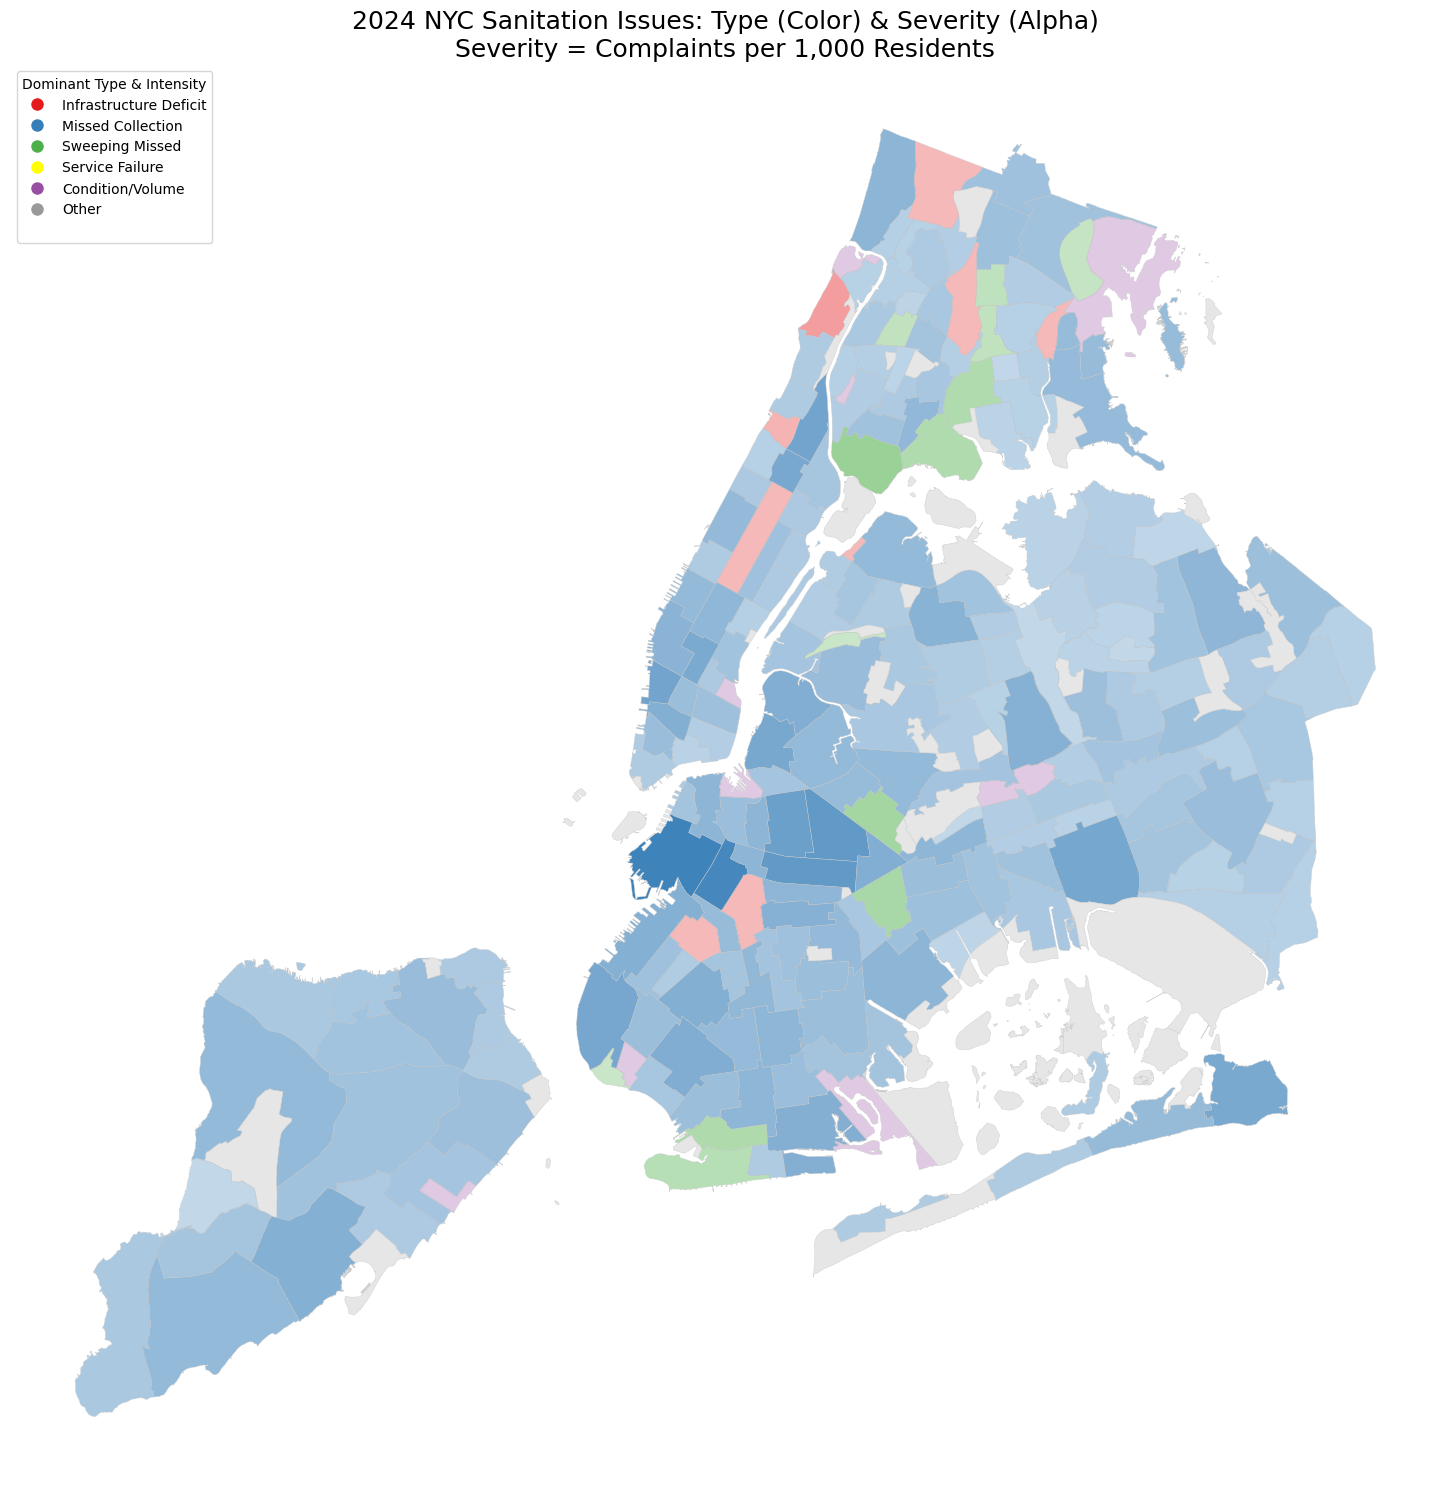

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D 
import zipfile
import os
import numpy as np


zip_file_path = 'nynta2020_25d.zip' 
extract_dir = 'nynta2020_25d'

if not os.path.exists(extract_dir):
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
    except: pass
shp_file_path = os.path.join(extract_dir, 'nynta2020_25d', 'nynta2020.shp')

try:
    df_pop = pd.read_csv('../tonnage/New_York_City_Population_By_Community_Districts_20251123.csv')
    
    def clean_pop(val):
        if isinstance(val, str): return float(val.replace(',', ''))
        return float(val)
    
    df_pop['Population'] = df_pop['2010 Population'].apply(clean_pop)
    
    b_map = {'Manhattan': 'MN', 'Bronx': 'BX', 'Brooklyn': 'BK', 'Queens': 'QN', 'Staten Island': 'SI'}
    df_pop['CD_ID'] = df_pop['Borough'].map(b_map) + df_pop['CD Number'].astype(str).str.zfill(2)
    
    pop_dict = df_pop.set_index('CD_ID')['Population'].to_dict()
    print("Population data loaded.")
except Exception as e:
    print(f"Warning: Could not load population data ({e}). Alpha will be based on raw counts.")
    pop_dict = {}


csv_path = '311_compliants.csv'
df_complaints = pd.read_csv(csv_path)

filter_time = '2024'  

print(f"Filtering complaints for: {filter_time}")
df_complaints = df_complaints[df_complaints['year_month'].astype(str).str.startswith(filter_time)].copy()
print(f"Records found for {filter_time}: {len(df_complaints)}")

# print(f"Original records: {len(df_complaints)}")
# df_complaints = df_complaints[df_complaints['Complaint Type'] != 'Request Large Bulky Item Collection']
# print(f"Records after exclusion: {len(df_complaints)}")


category_map = {
    'Litter Basket Request': 'Infrastructure Deficit',
    'Litter Basket / Request': 'Infrastructure Deficit',
    'Adopt-A-Basket': 'Infrastructure Deficit',
    
    'Missed Collection': 'Missed Collection',
    'Missed Collection (All Materials)': 'Missed Collection',

    'Sweeping/Missed': 'Sweeping Missed',
    'Sweeping/Missed-Inadequate': 'Sweeping Missed',
    'Sweeping/Inadequate': 'Sweeping Missed',
    'Street Sweeping Complaint': 'Sweeping Missed',

    'Collection Truck Noise': 'Service Failure',
    'Request Large Bulky Item Collection': 'Service Failure',
    'Request Xmas Tree Collection': 'Service Failure',
    
    'Overflowing Litter Baskets': 'Condition/Volume',
    'Overflowing Recycling Baskets': 'Condition/Volume',
    'Litter Basket Complaint': 'Condition/Volume',
    'Recycling Basket Complaint': 'Condition/Volume'
}
df_complaints['Complaint_Category'] = df_complaints['Complaint Type'].map(category_map).fillna('Other')

nta_totals = df_complaints.groupby('NTA2020')['complaint_count'].sum().reset_index(name='Total_Complaints')

nta_cat_counts = df_complaints.groupby(['NTA2020', 'Complaint_Category'])['complaint_count'].sum().reset_index()
df_dominant = nta_cat_counts.sort_values('complaint_count', ascending=False).drop_duplicates('NTA2020')
df_dominant = df_dominant[['NTA2020', 'Complaint_Category']].rename(columns={'Complaint_Category': 'Dominant_Type'})

df_subset = pd.merge(df_dominant, nta_totals, on='NTA2020', how='left')
df_subset['NTA2020'] = df_subset['NTA2020'].astype(str)

df_subset['CD_ID'] = df_subset['NTA2020'].str[:4]
df_subset['Population'] = df_subset['CD_ID'].map(pop_dict)
df_subset['Intensity'] = (df_subset['Total_Complaints'] / df_subset['Population']) * 1000
df_subset['Intensity'] = df_subset['Intensity'].replace([np.inf, -np.inf], 0).fillna(0)


print(df_subset.describe())

color_mapping = {
    'Infrastructure Deficit': '#e41a1c', 
    'Missed Collection':      '#377eb8', 
    'Sweeping Missed':        '#4daf4a', 
    'Service Failure':        '#ffff00', 
    'Condition/Volume':       '#984ea3',
    'Other':                  '#999999'  
}

def get_rgba(row):
    cat = row['Dominant_Type']
    base_hex = color_mapping.get(cat, '#999999')
    r, g, b = mcolors.to_rgb(base_hex)
    intensity_cap = 7.0 
    
    val = row['Intensity']
    alpha = 0.3 + 0.7 * (min(val, intensity_cap) / intensity_cap)
    
    return (r, g, b, alpha)

try:
    nyc_nta_geo = gpd.read_file(shp_file_path)
    nyc_nta_geo['NTA2020'] = nyc_nta_geo['NTA2020'].astype(str)
    
    nta_merged = nyc_nta_geo.merge(df_subset, on='NTA2020', how='left')

    nta_merged['plot_color'] = nta_merged.apply(
        lambda row: get_rgba(row) if pd.notnull(row['Dominant_Type']) else (0.9, 0.9, 0.9, 1), 
        axis=1
    )

    fig, ax = plt.subplots(1, 1, figsize=(15, 15))

    nta_merged.plot(
        color=nta_merged['plot_color'], 
        linewidth=0.3,
        ax=ax,
        edgecolor='0.8'
    )

    legend_elements = []
    for cat, color in color_mapping.items():
        legend_elements.append(Line2D([0], [0], marker='o', color='w', label=cat,
                                      markerfacecolor=color, markersize=10))
    legend_elements.append(Line2D([0], [0], marker='', color='w', label=' ', markersize=0))
    ax.legend(handles=legend_elements, loc='upper left', title='Dominant Type & Intensity', frameon=True)
    ax.set_title('2024 NYC Sanitation Issues: Dominant Complaint Type by Neighborhood \nType (Color) & Severity (Alpha)\nSeverity = Complaints per 1,000 Residents', fontsize=18)
    ax.set_axis_off() 

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")